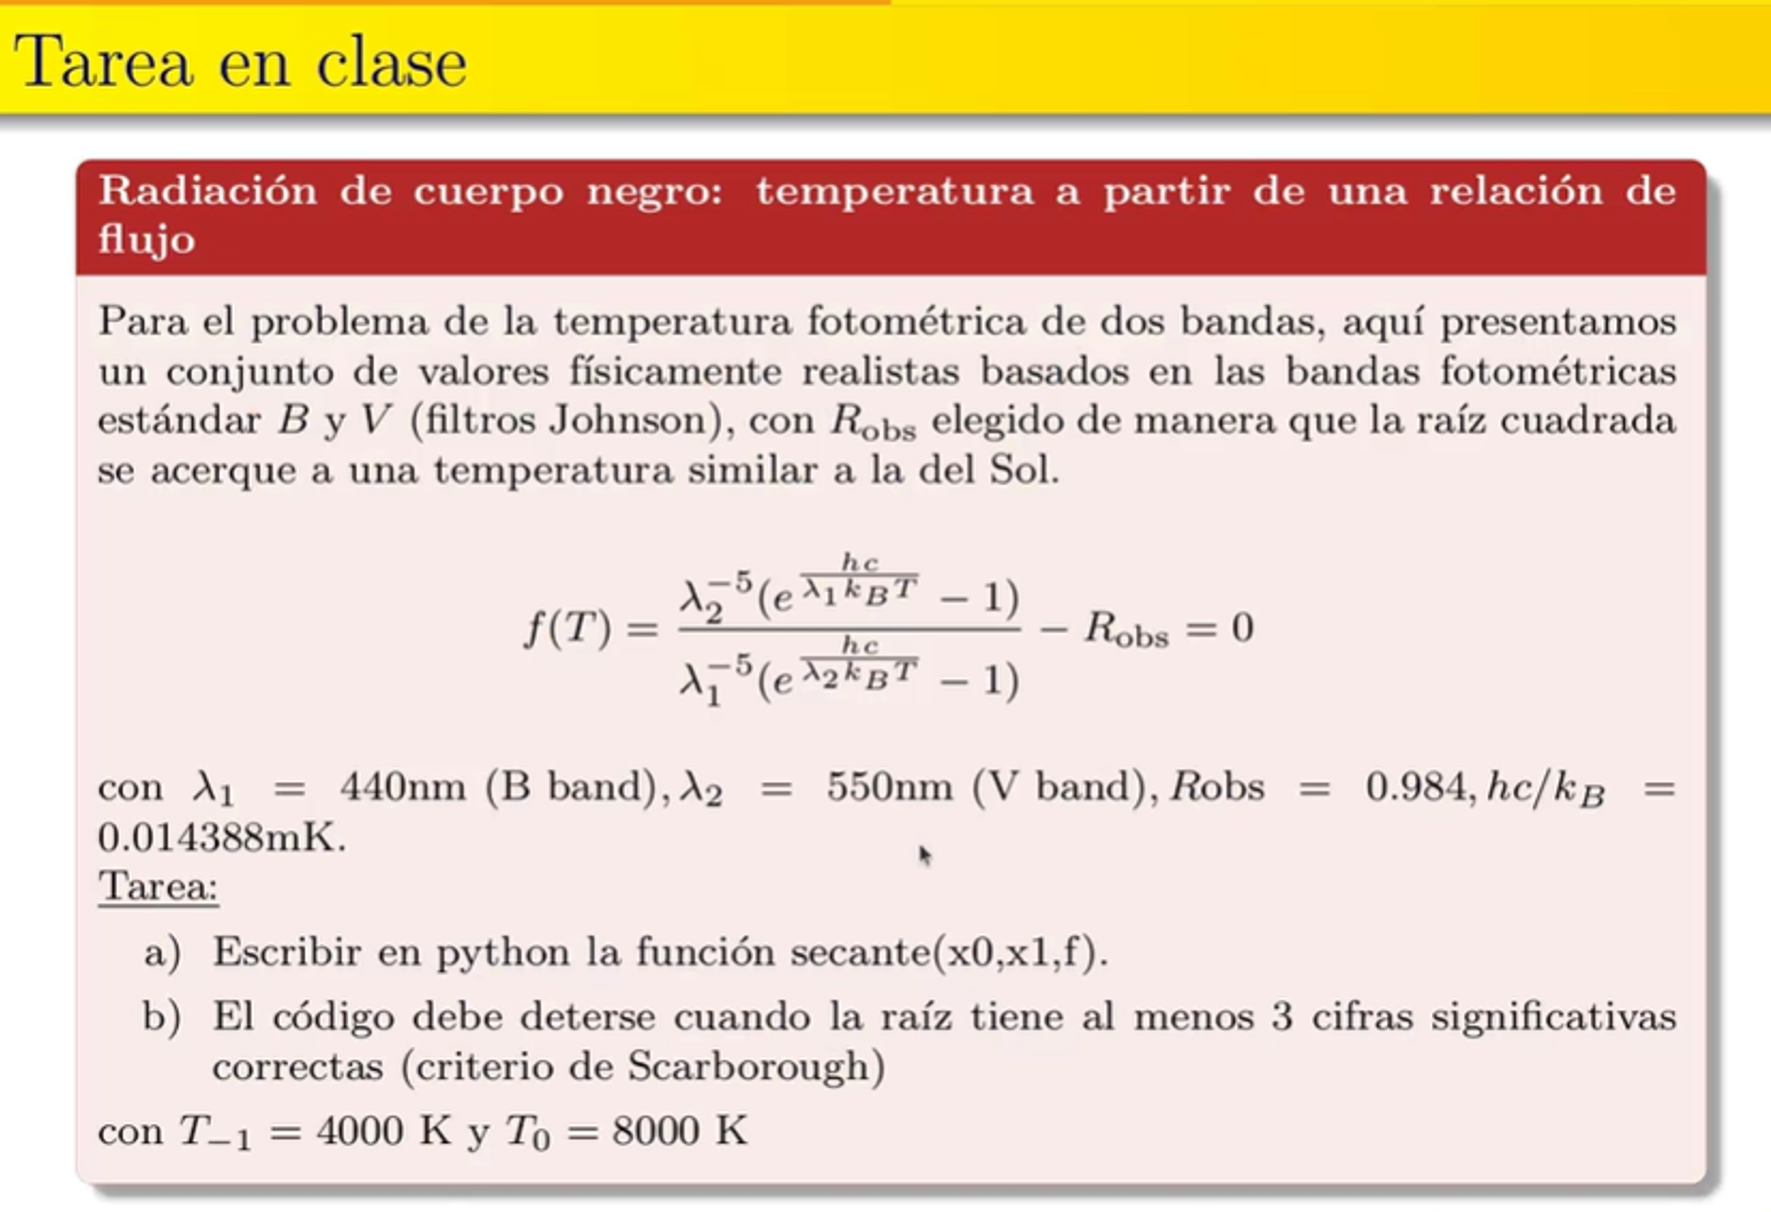

In [2]:
import numpy as np

# Parametros fisicos
lambda_1 = 440e-9
lambda_2 = 550e-9
R_obs = 0.984
hc_kB = 0.014388

# Criterio de Scarborough para n = 3 cifras significativas
n_cifras = 3
es = 0.5 * (10.0 ** (2.0 - n_cifras))

# Valores iniciales de temperatura
T_prev = 4000.0
T_curr = 8000.0

# Evaluacion inicial de la funcion  (4000 K)
exp1_prev = np.exp(hc_kB / (lambda_1 * T_prev)) - 1.0
exp2_prev = np.exp(hc_kB / (lambda_2 * T_prev)) - 1.0
f_prev = ((lambda_2**(-5.0)) * exp1_prev) / ((lambda_1**(-5.0)) * exp2_prev) - R_obs

# Evaluacion inicial de la funcion (8000 K)
exp1_curr = np.exp(hc_kB / (lambda_1 * T_curr)) - 1.0
exp2_curr = np.exp(hc_kB / (lambda_2 * T_curr)) - 1.0
f_curr = ((lambda_2**(-5.0)) * exp1_curr) / ((lambda_1**(-5.0)) * exp2_curr) - R_obs

iteracion = 0
ea = 100

# Bucle del metodo de la secante
while ea > es:
    iteracion = iteracion + 1
    
    # Formula del metodo de la secante
    T_next = T_curr - (f_curr * (T_curr - T_prev)) / (f_curr - f_prev)
    
    # Error relativo
    ea = abs((T_next - T_curr) / T_next) * 100
    
    # Evaluacion de la funcion en el nuevo punto T_next
    exp1_next = np.exp(hc_kB / (lambda_1 * T_next)) - 1.0
    exp2_next = np.exp(hc_kB / (lambda_2 * T_next)) - 1.0
    f_next = ((lambda_2**(-5.0)) * exp1_next) / ((lambda_1**(-5.0)) * exp2_next) - R_obs
    
    # Actualizacion de variables
    T_prev = T_curr
    f_prev = f_curr
    T_curr = T_next
    f_curr = f_next

# resultados
print("RESULTADOS DEL MÉTODO DE LA SECANTE")
print("Se encontro la temperatura en la iteracion:", iteracion)
print("Temperatura obtenida T:", T_curr, "K")
print("Error relativo porcentual aproximado (ea):", ea, "%")
print("Tolerancia del Criterio de Scarborough (es):", es, "%")

RESULTADOS DEL MÉTODO DE LA SECANTE
Se encontro la temperatura en la iteracion: 6
Temperatura obtenida T: 5994.147684907499 K
Error relativo porcentual aproximado (ea): 0.016419085924731847 %
Tolerancia del Criterio de Scarborough (es): 0.05 %
